<a href="https://colab.research.google.com/github/juizykad-netizen/AIML_PYTHON/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
# Create model → Fit model → Predict → Evaluate
#1 Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [69]:
# 2Load the Dataset
df = pd.read_csv("/content/car details v4.csv")   # change to your dataset file name
df.head()


,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [70]:
# 3Data Exploration
# 3.1-Dataset Shape & Info
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [71]:
# 3.2-Statistical Summary
df.describe()


,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [72]:
# 3.3 Check Missing Values
df.isnull().sum()


,0
Make,0
Model,0
Price,0
Year,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Color,0
Owner,0


In [73]:
# Clean Engine Column
df['Engine'] = df['Engine'].astype(str)  # make sure it's string
df['Engine'] = df['Engine'].str.extract('(\d+\.?\d*)')  # extract number only
df['Engine'] = pd.to_numeric(df['Engine'], errors='coerce')



<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1668701587.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['Engine'] = df['Engine'].str.extract('(\d+\.?\d*)')  # extract number only


In [74]:
# Clean Max Power
df['Max Power'] = df['Max Power'].astype(str)
df['Max Power'] = df['Max Power'].str.extract('(\d+\.?\d*)')
df['Max Power'] = pd.to_numeric(df['Max Power'], errors='coerce')


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-2264784663.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['Max Power'] = df['Max Power'].str.extract('(\d+\.?\d*)')


In [75]:
# Clean Max Torque
df['Max Torque'] = df['Max Torque'].astype(str)
df['Max Torque'] = df['Max Torque'].str.extract('(\d+\.?\d*)')
df['Max Torque'] = pd.to_numeric(df['Max Torque'], errors='coerce')


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-497752860.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['Max Torque'] = df['Max Torque'].str.extract('(\d+\.?\d*)')


In [76]:
# Handle Missing Values Created After Conversion
df[['Engine', 'Max Power', 'Max Torque']] = df[['Engine', 'Max Power', 'Max Torque']].fillna(df[['Engine', 'Max Power', 'Max Torque']].median())


In [77]:
# df[['Engine', 'Max Power', 'Max Torque']].dtypes
df[['Engine', 'Max Power', 'Max Torque']].dtypes


,0
Engine,float64
Max Power,float64
Max Torque,float64


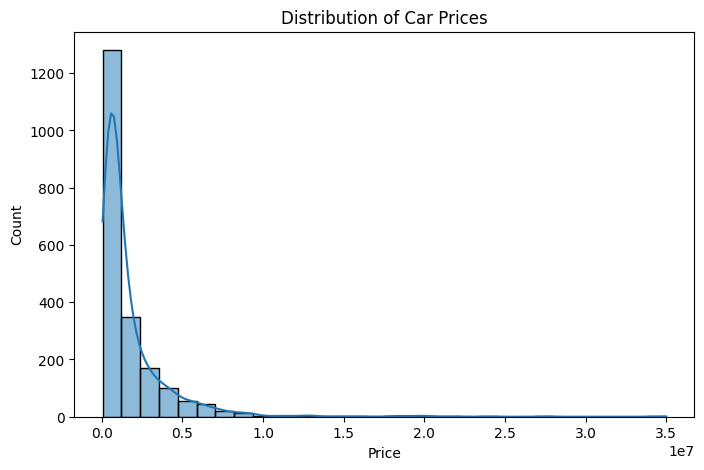

In [78]:
# 4.Exploratory Data Analysis (EDA)
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Distribution of Car Prices")
plt.show()


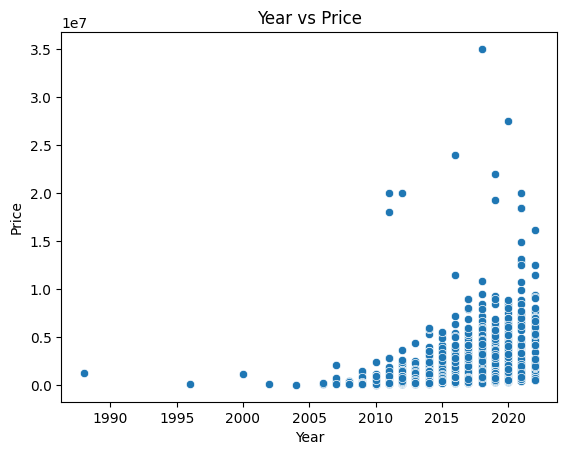

In [79]:
# Year vs Price
sns.scatterplot(x='Year', y='Price', data=df)
plt.title("Year vs Price")
plt.show()


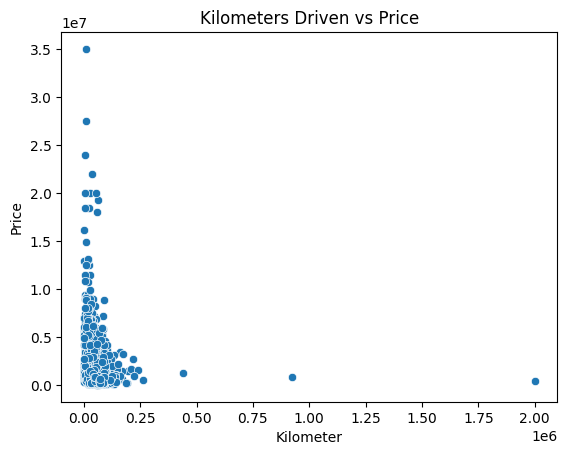

In [80]:
# Kilometer vs Price
sns.scatterplot(x='Kilometer', y='Price', data=df)
plt.title("Kilometers Driven vs Price")
plt.show()


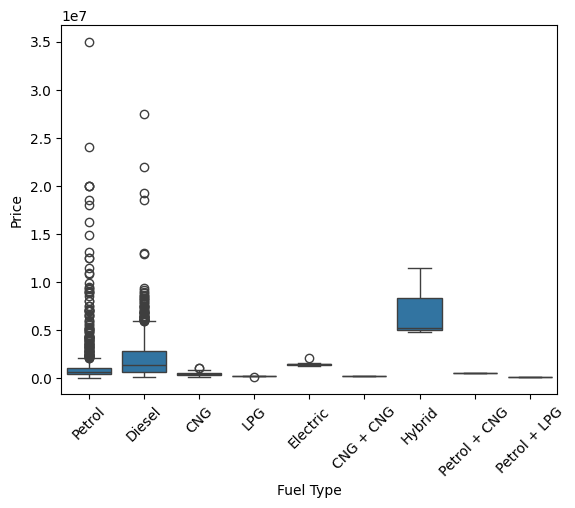

In [81]:
# Fuel Type vs Price
sns.boxplot(x='Fuel Type', y='Price', data=df)
plt.xticks(rotation=45)
plt.show()
# Newer cars → higher price

# More kilometers → lower price

# Diesel cars often priced higher

In [82]:
# 5.Data Preprocessing
# 5.1 Handle Missing Values
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna("Unknown", inplace=True)


In [83]:
# 5.2 Encode Categorical Variables
# We convert text columns into numbers.
le = LabelEncoder()

categorical_cols = ['Make', 'Model', 'Fuel Type', 'Transmission',
                    'Location', 'Color', 'Seller Type', 'Owner', 'Drivetrain']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))


In [84]:
# 5.3 Feature & Target Split
X = df.drop('Price', axis=1)
y = df['Price']


In [85]:
# 5.4 Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [86]:
# Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [87]:
# 7Train the Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)   # 👈 MODEL LEARNS HERE



LinearRegression()

In [88]:
# Make Predictions
y_pred = model.predict(X_test)   # 👈 NOW it works






In [89]:
# 9: Evaluate
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 1923610548607.0852
R2 Score: 0.724658910630342


In [90]:
# R-squared Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

# MSE shows average prediction error

# R² shows how well features explain price variation (closer to 1 = better)

R2 Score: 0.724658910630342


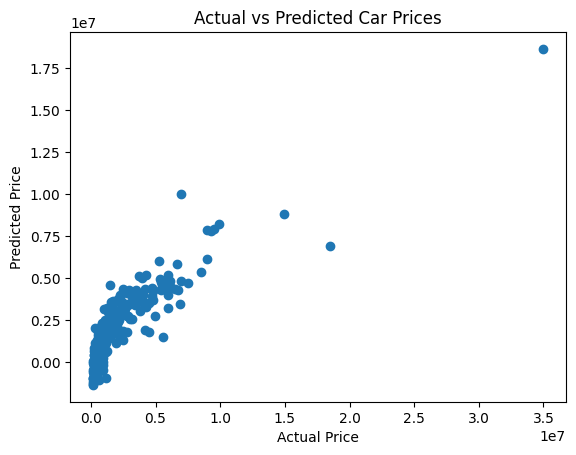

In [91]:
# 10: Actual vs Predicted Price
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()


In [92]:
# 11: Feature Importance (Model Coefficients)
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coefficients.sort_values(by='Coefficient', ascending=False)
# Positive coefficient → increases price (e.g., newer year, higher engine power)

# Negative coefficient → decreases price (e.g., more kilometers driven)

,Coefficient
Max Power,2.053092e+06
Year,5.190466e+05
Fuel Tank Capacity,2.682448e+05
Make,1.505594e+05
Height,1.211593e+05
Drivetrain,7.285145e+04
Owner,4.848242e+04
Seller Type,3.866607e+02
Transmission,-1.524743e+03
Max Torque,-1.186425e+04


Built a Linear Regression model to predict car prices

Features like Year, Engine, Power, Kilometer strongly influence price

Model performance evaluated using MSE and R² score

This model can help sellers estimate a fair car price